# Форматы обмена данными. Семантическая аннотация.

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Дан текст, содержащий информацию об А.С. Пушкине. Выделите из этого текста сущности при помощи обращения к инструменту DBPedia Spotlight (используйте API, который предоставляет данный инструмент). Исследуйте, как зависит количество выделенных сущностей от уровня уверенности `confidence`).

Выведите на экран набор выделенных сущностей в виде JSON.

- [ ] Проверено на семинаре

In [1]:
!pip install python-docx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 15.2 MB/s eta 0:00:00


In [2]:
from typing import Any, Dict, List, Optional
from docx import Document
import requests
import json
import time


In [3]:
# Читает текст из .docx-файла и возвращает объединённый текст
def read_docx_text(path: str) -> str:
    doc = Document(path)
    paragraphs: List[str] = [p.text for p in doc.paragraphs if p.text and p.text.strip()]
    return "\n".join(paragraphs)

# Вызывает DBpedia Spotlight API для одного фрагмента текста и заданного confidence
def annotate_text_dbpedia_spotlight(
    text: str,
    confidence: float,
    support: int = 0,
    lang: str = "ru",
    endpoint: Optional[str] = None,
    timeout: int = 30,
) -> Dict[str, Any]:
    if endpoint is None:
        # официальный публичный endpoint (может быть недоступен/ограничен). Для разных языков можно менять subpath.
        endpoint = f"https://api.dbpedia-spotlight.org/{lang}/annotate"
    headers = {"Accept": "application/json"}
    params = {
        "confidence": f"{confidence}",
        "support": f"{support}"
    }
    # Spotlight обычно поддерживает POST с полем 'text'
    try:
        resp = requests.post(endpoint, params=params, data={"text": text}, headers=headers, timeout=timeout)
        resp.raise_for_status()
        return resp.json()
    except requests.HTTPError as e:
        # вернём информацию об ошибке для отладки
        return {"error": f"HTTPError: {e}", "status_code": getattr(e.response, "status_code", None), "text": getattr(e.response, "text", None)}
    except requests.RequestException as e:
        return {"error": f"RequestException: {e}"}

# Нормализует вывод Spotlight в удобную структуру сущностей
def parse_spotlight_response(response: Dict[str, Any]) -> List[Dict[str, Any]]:
    if not response or "Resources" not in response:
        return []
    resources = response["Resources"]
    parsed: List[Dict[str, Any]] = []
    # Каждый ресурс содержит поля в виде атрибутов со строковыми ключами
    for r in resources:
        ent = {
            "surfaceForm": r.get("@surfaceForm"),
            "uri": r.get("@URI"),
            "types": r.get("@types"),
            "similarityScore": r.get("@similarityScore"),
            "offset": r.get("@offset"),
        }
        parsed.append(ent)
    return parsed

# Разбивает длинный текст на куски длиной <= max_chars (простой безопасный разрез по границе слов)
def chunk_text(text: str, max_chars: int = 3000) -> List[str]:
    if len(text) <= max_chars:
        return [text]
    chunks: List[str] = []
    start = 0
    while start < len(text):
        end = min(len(text), start + max_chars)
        if end < len(text):
            # откат до последнего пробела, чтобы не резать внутри слова
            last_space = text.rfind(" ", start, end)
            if last_space > start:
                end = last_space
        chunks.append(text[start:end].strip())
        start = end
    return [c for c in chunks if c]

# Основная функция: для набора confidence вызывает API и собирает уникальные сущности
def extract_entities_for_confidences(
    text: str,
    confidences: List[float],
    support: int = 0,
    lang: str = "ru",
    pause_between_requests: float = 0.5,
) -> Dict[float, List[Dict[str, Any]]]:
    # Если текст длинный, разобьём на чанки и объединим результаты (с сохранением offset как строк)
    chunks = chunk_text(text, max_chars=3000)
    results: Dict[float, List[Dict[str, Any]]] = {}
    for conf in confidences:
        seen_uris = set()
        entities_for_conf: List[Dict[str, Any]] = []
        for chunk in chunks:
            resp = annotate_text_dbpedia_spotlight(chunk, confidence=conf, support=support, lang=lang)
            parsed = parse_spotlight_response(resp)
            # Добавляем уникальные сущности по URI + surfaceForm (на случай, если URI отсутствует)
            for p in parsed:
                key = (p.get("uri") or "") + "||" + (p.get("surfaceForm") or "")
                if key not in seen_uris:
                    seen_uris.add(key)
                    entities_for_conf.append(p)
            time.sleep(pause_between_requests)  # аккуратное ожидание между вызовами
        results[conf] = entities_for_conf
    return results

# Утилита для печати результатов в JSON на экран (с utf-8)
def print_results_as_json(results: Dict[float, List[Dict[str, Any]]]) -> None:
    # Преобразуем ключи (float) в строки для JSON-совместимости
    serializable: Dict[str, Any] = {str(k): v for k, v in results.items()}
    print(json.dumps(serializable, ensure_ascii=False, indent=2))

path = "Александр Сергеевич Пушкин.docx"
text = read_docx_text(path)
# Подбираем несколько уровней confidence для исследования
confidences = [0.1, 0.3, 0.5, 0.7, 0.9]
results = extract_entities_for_confidences(text, confidences, support=0, lang="ru", pause_between_requests=0.6)
print_results_as_json(results)

{
  "0.1": [
    {
      "surfaceForm": "Александр Сергеевич Пушкин",
      "uri": "http://ru.dbpedia.org/resource/Пушкин,_Александр_Сергеевич",
      "types": "Http://xmlns.com/foaf/0.1/Person,Wikidata:Q729,Wikidata:Q5,Wikidata:Q36180,Wikidata:Q215627,Wikidata:Q19088,DUL:NaturalPerson,Schema:Person,DBpedia:Species,DBpedia:Person,DBpedia:Eukaryote,DBpedia:Animal,DBpedia:Writer",
      "similarityScore": "0.9999973316029486",
      "offset": "0"
    },
    {
      "surfaceForm": "России",
      "uri": "http://ru.dbpedia.org/resource/Россия",
      "types": "Wikidata:Q6256,Schema:Place,Schema:Country,DBpedia:PopulatedPlace,DBpedia:Place,DBpedia:Location,DBpedia:Country",
      "similarityScore": "0.9948358194269263",
      "offset": "154"
    },
    {
      "surfaceForm": "Москве",
      "uri": "http://ru.dbpedia.org/resource/Москва",
      "types": "Schema:Place,DBpedia:Place,DBpedia:Location,DBpedia:PopulatedPlace",
      "similarityScore": "0.999842668132903",
      "offset": "270"
  

<p class="task" id="2"></p>

2\. Разметьте текст с использованием RDFa (Resource Description Framework in Attributes) на основе предоставленных данных из DBPedia Spotlight.

Вы должны обернуть весь текст в div-элемент с атрибутами vocab="http://schema.org/" и typeof="Article", чтобы указать, что это статья, описанная с использованием словаря Schema.org.

Далее, вам нужно разметить различные части текста, используя подходящие свойства из Schema.org. Основные правила:
* информацию об Александре Пушкине следует обернуть в span с property="author" и typeof="Person".
* имя должно быть помещено в отдельный span с property="name", а ссылка на его страницу в DBpedia должна быть добавлена с помощью атрибута property="sameAs".
* место рождения Пушкина (Москва) должно быть обозначено как property="birthPlace" с typeof="Place", а дата рождения - как property="birthDate".
* упомянутые произведения должны быть размечены как property="mentions" с typeof="Book" и указать название внутри span с property="name"
* при упоминании других личностей используйте property="knows" с typeof="Person", также добавляя соответствующую ссылку на DBpedia
* географические объекты следует разметить с использованием property="contentLocation" и typeof="Country".и т.д.

Не забудьте добавить ссылки на соответствующие ресурсы DBpedia, где это возможно.

Полученное RDFa представление протестируйте на сайте https://rdfa.info/play/ и вставьте скриншот с полученным графом сущностей.

- [ ] Проверено на семинаре

In [6]:
!pip install rdflib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 569.0/569.0 kB 23.8 MB/s eta 0:00:00


In [9]:
from rdflib import Graph, Namespace, URIRef, BNode, Literal
from rdflib.namespace import RDF, XSD
import re

In [8]:
SCHEMA = Namespace("http://schema.org/")

In [12]:
# Получаем список сущностей из результатов Spotlight — выбираем набор с максимальным confidence
def select_entities_from_results(results: Dict[str, Any]) -> List[Dict[str, Any]]:
    keys = list(results.keys())
    # ключи могут быть float или str; приводим к float для сравнения
    confidences = [float(k) for k in keys]
    max_conf = str(max(confidences))
    return results[max_conf]

# Строим rdflib.Graph: статья -> автор, книги, места и т.д.
def build_graph_from_entities(text: str, entities: List[Dict[str, Any]]) -> Graph:
    g = Graph()
    g.bind("schema", SCHEMA)
    article_node = BNode()
    g.add((article_node, RDF.type, SCHEMA.Article))

    # простая эвристика: автор — сущность, содержащая 'Пушкин' в surfaceForm или первая Person
    author_node = None
    for e in entities:
        sf = (e.get("surfaceForm") or "").lower()
        if "пушкин" in sf:
            uri = e.get("uri")
            author_node = URIRef(uri) if uri else BNode()
            g.add((article_node, SCHEMA.author, author_node))
            g.add((author_node, RDF.type, SCHEMA.Person))
            name = e.get("surfaceForm")
            if name:
                g.add((author_node, SCHEMA.name, Literal(name)))
            if uri:
                g.add((author_node, SCHEMA.sameAs, URIRef(uri)))
            break
    # если автора не нашли по Пушкину, взять первую сущность типа Person
    if author_node is None:
        for e in entities:
            types = e.get("types", "")
            if "Person" in types or "DBpedia:Person" in types or "Schema:Person" in types:
                uri = e.get("uri")
                author_node = URIRef(uri) if uri else BNode()
                g.add((article_node, SCHEMA.author, author_node))
                g.add((author_node, RDF.type, SCHEMA.Person))
                name = e.get("surfaceForm")
                if name:
                    g.add((author_node, SCHEMA.name, Literal(name)))
                if uri:
                    g.add((author_node, SCHEMA.sameAs, URIRef(uri)))
                break

    # обработка остальных сущностей: книги -> mentions Book, места -> contentLocation Country/Place, люди -> knows
    for e in entities:
        sf = e.get("surfaceForm") or ""
        uri = e.get("uri")
        types = e.get("types", "")
        node = URIRef(uri) if uri else BNode()

        # книги / произведения
        if any(k in types for k in ("Work", "Book", "CreativeWork", "Schema:Book", "schema:Book")) or re.search(r"(роман|поэма|сказка|произведение|повесть)", sf, flags=re.IGNORECASE):
            g.add((article_node, SCHEMA.mentions, node))
            g.add((node, RDF.type, SCHEMA.Book))
            g.add((node, SCHEMA.name, Literal(sf)))
            if uri:
                g.add((node, SCHEMA.sameAs, URIRef(uri)))
            continue

        # географические объекты
        if any(k in types for k in ("Place", "Location", "Country", "PopulatedPlace", "geo:SpatialThing")) or sf.lower() in ("москва", "санкт-петербург", "петербург", "спб"):
            g.add((article_node, SCHEMA.contentLocation, node))
            g.add((node, RDF.type, SCHEMA.Country if "Country" in types else SCHEMA.Place))
            g.add((node, SCHEMA.name, Literal(sf)))
            if uri:
                g.add((node, SCHEMA.sameAs, URIRef(uri)))
            continue

        # лица (кроме автора) — knows
        if any(k in types for k in ("Person", "DBpedia:Person", "schema:Person")) and (author_node is None or (uri and str(author_node) != uri)):
            g.add((article_node, SCHEMA.knows, node))
            g.add((node, RDF.type, SCHEMA.Person))
            g.add((node, SCHEMA.name, Literal(sf)))
            if uri:
                g.add((node, SCHEMA.sameAs, URIRef(uri)))
            continue

    # попытка найти дату рождения в сущностях (если есть surfaceForm, похожая на дату)
    for e in entities:
        sf = e.get("surfaceForm") or ""
        if re.match(r"\d{1,2}\.\d{1,2}\.\d{4}", sf) or re.match(r"\d{4}-\d{2}-\d{2}", sf) or re.search(r"\b\d{4}\b", sf):
            if author_node is not None:
                # взяли первый попавшийся год/дату как birthDate
                g.add((author_node, SCHEMA.birthDate, Literal(sf, datatype=XSD.date)))
                break

    return g

# Формируем HTML с RDFa: оборачиваем текст, подставляя span для сущностей.
def generate_rdfa_html(text: str, entities: List[Dict[str, Any]]) -> str:
    # Используем оффсеты, если есть — собираем (start, end, entity)
    offsets: List[Tuple[int, int, Dict[str, Any]]] = []
    for e in entities:
        off = e.get("offset")
        sf = e.get("surfaceForm") or ""
        if off is not None and str(off).isdigit():
            start = int(off)
            end = start + len(sf)
            offsets.append((start, end, e))
    # если есть offsets — используем их (вставляем теги по смещениям)
    if offsets:
        offsets_sorted = sorted(offsets, key=lambda x: x[0])
        parts: List[str] = []
        last = 0
        for start, end, e in offsets_sorted:
            if start < last:
                continue
            parts.append(escape_html(text[last:start]))
            parts.append(entity_to_rdfa_span(e))
            last = end
        parts.append(escape_html(text[last:]))
        body = "".join(parts)
    else:
        # fallback: последовательная замена первых вхождений surfaceForm
        body = text
        for e in entities:
            sf = e.get("surfaceForm") or ""
            if not sf:
                continue
            body = replace_first_occurrence(body, sf, entity_to_rdfa_span(e))
    # Обёртка Article
    html = f'<div vocab="http://schema.org/" typeof="Article">\n{body}\n</div>'
    return html

# Маленькие хелперы
def escape_html(s: str) -> str:
    return (s.replace("&", "&amp;").replace("<", "&lt;").replace(">", "&gt;")
            .replace('"', "&quot;").replace("'", "&#39;"))

def replace_first_occurrence(text: str, old: str, new: str) -> str:
    return re.sub(re.escape(old), new, text, count=1)

def entity_to_rdfa_span(e: Dict[str, Any]) -> str:
    sf = e.get("surfaceForm") or ""
    uri = e.get("uri")
    types = e.get("types", "")
    sf_escaped = escape_html(sf)
    # простая эвристика для выбора property/typeof
    if "пушкин" in sf.lower() or "person" in types or "Person" in types:
        prop = 'property="author" typeof="Person"'
        name_span = f'<span property="name">{sf_escaped}</span>'
        sameas = f' <a property="sameAs" href="{uri}">{uri}</a>' if uri else ""
        return f'<span {prop}>{name_span}{sameas}</span>'
    if any(k in types for k in ("Work", "Book", "CreativeWork", "schema:Book", "Book")) or re.search(r"(роман|поэма|повесть|сказка|повесть)", sf, flags=re.IGNORECASE):
        name_span = f'<span property="name">{sf_escaped}</span>'
        sameas = f' <a property="sameAs" href="{uri}">{uri}</a>' if uri else ""
        return f'<span property="mentions" typeof="Book">{name_span}{sameas}</span>'
    if any(k in types for k in ("Place", "Location", "Country")) or sf.lower() in ("москва",):
        sameas = f' <a property="sameAs" href="{uri}">{uri}</a>' if uri else ""
        return f'<span property="contentLocation" typeof="Place"><span property="name">{sf_escaped}</span>{sameas}</span>'
    # по умолчанию — пометить как упоминание
    sameas = f' <a property="sameAs" href="{uri}">{uri}</a>' if uri else ""
    return f'<span property="mentions">{sf_escaped}{sameas}</span>'

In [14]:
# исправленный короткий код для Jupyter — выбирает максимальный confidence и продолжает
from typing import Dict

# выбираем ключ с наибольшим численным значением (оставляем строковый ключ как есть)
best_key = max(results.keys(), key=lambda k: float(k))
entities_selected = results[best_key]

# запускаем уже определённые ранее функции (build_graph_from_entities, generate_rdfa_html)
graph = build_graph_from_entities(text, entities_selected)
rdfa_html = generate_rdfa_html(text, entities_selected)

# печать Turtle (rdflib иногда возвращает str, иногда bytes)
t = graph.serialize(format="turtle")
print("=== selected confidence ===", best_key)
print("\n=== RDF (Turtle) ===")
print(t.decode() if isinstance(t, (bytes, bytearray)) else t)
print("\n=== RDFa HTML ===")
print(rdfa_html)

# положим результаты в переменные для дальнейшего использования
rdf_graph = graph
rdfa_output = rdfa_html


=== selected confidence === 0.9

=== RDF (Turtle) ===
@prefix schema1: <http://schema.org/> .

<http://ru.dbpedia.org/resource/Гончарова,_Наталья_Николаевна> a schema1:Person ;
    schema1:name "Наталье Гончаровой" ;
    schema1:sameAs <http://ru.dbpedia.org/resource/Гончарова,_Наталья_Николаевна> .

<http://ru.dbpedia.org/resource/Императорский_Царскосельский_лицей> a schema1:Person ;
    schema1:name "Царскосельский лицей" ;
    schema1:sameAs <http://ru.dbpedia.org/resource/Императорский_Царскосельский_лицей> .

<http://ru.dbpedia.org/resource/Москва> a schema1:Place ;
    schema1:name "Москве" ;
    schema1:sameAs <http://ru.dbpedia.org/resource/Москва> .

<http://ru.dbpedia.org/resource/Одесса> a schema1:Place ;
    schema1:name "Одессе" ;
    schema1:sameAs <http://ru.dbpedia.org/resource/Одесса> .

<http://ru.dbpedia.org/resource/Пушкин,_Александр_Сергеевич> a schema1:Person ;
    schema1:name "Александр Сергеевич Пушкин" ;
    schema1:sameAs <http://ru.dbpedia.org/resource/Пушк

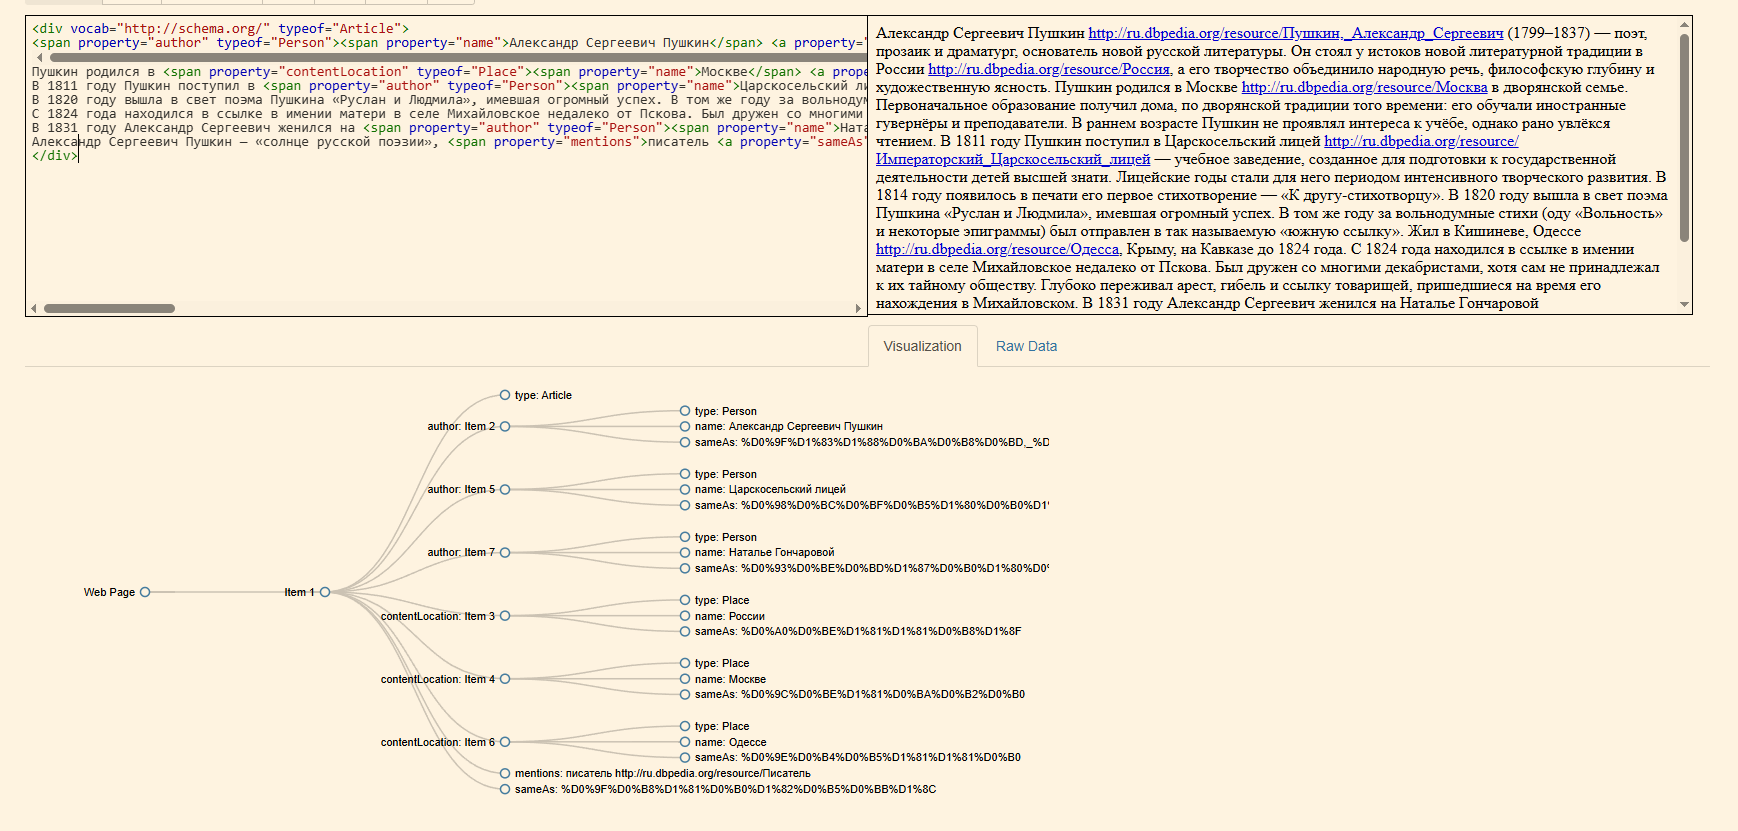

<p class="task" id="3"></p>

3\. Повторите задачу 2, представив результат в формате JSON-LD.

Основная структура JSON-LD должна представлять статью (Article) и включать в себя следующие ключевые элементы:

* информацию об Александре Пушкине как об авторе (author) типа Person. Укажите его имя (name) и ссылку на страницу в DBpedia (sameAs).
* место рождения Пушкина (birthPlace) как отдельный объект типа Place, включая название и ссылку на соответствующий ресурс DBpedia.
* дату рождения Пушкина (birthDate).
* Упомянутые произведения следует представить как массив объектов в свойстве mentions, каждый с типом Book и указанием названия.
* Информацию об образовательном учреждении (Царскосельский лицей) можно включить в свойство about, используя тип EducationalOrganization.
* Для других упомянутых личностей (например, Александр Горчаков) используйте свойство knows, также с типом Person и ссылкой на DBpedia.
* Географические объекты (например, Россия) следует представить в свойстве contentLocation с типом Country.

При создании JSON-LD структуры, убедитесь, что вы используете правильные идентификаторы (@id) для сущностей, соответствующие ссылкам из DBpedia, где это возможно.

Полученное JSON-LD представление протестируйте на сайте https://json-ld.org/playground/ и вставьте скриншот с полученным графом сущностей.

- [ ] Проверено на семинаре

In [15]:
# получить entities (если entities_selected уже есть, используем его; иначе выбираем лучший ключ)
if 'entities_selected' in globals():
    entities = entities_selected
else:
    best_key = max(results.keys(), key=lambda k: float(k))
    entities = results[best_key]

# хелперы — минимальные
def find_by_surface(sf_lower: str) -> Dict[str, Any]:
    for e in entities:
        if (e.get("surfaceForm") or "").lower().strip() == sf_lower:
            return e
    return {}

def find_person_author() -> Dict[str, Any]:
    for e in entities:
        sf = (e.get("surfaceForm") or "").lower()
        if "пушкин" in sf:
            return e
    for e in entities:
        types = e.get("types") or ""
        if "Person" in types or "person" in types:
            return e
    return {}

def find_country_named(name_lower: str) -> Dict[str, Any]:
    for e in entities:
        if (e.get("surfaceForm") or "").lower().strip() == name_lower:
            return e
    return {}

def persons_other_than(author_uri: str) -> List[Dict[str, Any]]:
    out = []
    for e in entities:
        uri = e.get("uri") or ""
        types = e.get("types") or ""
        if "Person" in types and uri != author_uri:
            out.append(e)
    return out

# собираем JSON-LD
author_ent = find_person_author()
author_uri = author_ent.get("uri")
author_name = author_ent.get("surfaceForm")

birthplace_ent = find_by_surface("москве") or find_by_surface("москва")
country_ent = find_by_surface("россии") or find_by_surface("россия")
school_ent = find_by_surface("царскосельский лицей") or find_by_surface("императорский царскосельский лицей")

# попытаемся найти дату рождения в тексте (ищем '1799' и возможную полную дату)
birth_date = None
m = re.search(r"(\d{1,2})\s+([А-Яа-яё]+)\s+1799", text)
if m:
    day = m.group(1).zfill(2)
    month_name = m.group(2).lower()
    months = {
        "января":"01","февраля":"02","марта":"03","апреля":"04","мая":"05","июня":"06",
        "июля":"07","августа":"08","сентября":"09","октября":"10","ноября":"11","декабря":"12"
    }
    mon = months.get(month_name)
    if mon:
        birth_date = f"1799-{mon}-{day}"
# если не нашли полную дату, но найден год в тексте — сохраняем год
if not birth_date and "1799" in text:
    birth_date = "1799"

# mentions: ищем сущности, которые по types похожи на Book или по surfaceForm на названия произведений (эвристически)
mentions_list = []
for e in entities:
    types = (e.get("types") or "")
    sf = e.get("surfaceForm") or ""
    if any(k in types for k in ("Book","CreativeWork","schema:Book","Schema:Book")) or re.search(r"(роман|поэма|сказка|повесть|стихи|поэмы)", sf, flags=re.IGNORECASE):
        mentions_list.append({
            "@type": "Book",
            "name": sf,
            **({"@id": e.get("uri")} if e.get("uri") else {})
        })

# knows: прочие персоны (исключая автора)
other_people = []
author_id = author_uri or ""
for p in persons_other_than(author_id):
    other_people.append({
        "@type": "Person",
        "name": p.get("surfaceForm"),
        **({"@id": p.get("uri")} if p.get("uri") else {})
    })

# contentLocation: страны/географические объекты (например, Россия)
content_locations = []
if country_ent:
    content_locations.append({
        "@type": "Country",
        "name": country_ent.get("surfaceForm"),
        **({"@id": country_ent.get("uri")} if country_ent.get("uri") else {})
    })

# about: образовательное учреждение
about_obj = None
if school_ent:
    about_obj = {
        "@type": "EducationalOrganization",
        "name": school_ent.get("surfaceForm"),
        **({"@id": school_ent.get("uri")} if school_ent.get("uri") else {})
    }

# финальная структура JSON-LD
jsonld: Dict[str, Any] = {
    "@context": "http://schema.org",
    "@type": "Article",
    "author": {
        "@type": "Person",
        "name": author_name,
        **({"@id": author_uri} if author_uri else {}),
        **({"sameAs": author_uri} if author_uri else {})
    },
    **({"birthPlace": {
        "@type": "Place",
        "name": birthplace_ent.get("surfaceForm"),
        **({"@id": birthplace_ent.get("uri")} if birthplace_ent.get("uri") else {})
    }} if birthplace_ent else {}),
    **({"birthDate": birth_date} if birth_date else {}),
    **({"mentions": mentions_list} if mentions_list else {"mentions": []}),
    **({"about": about_obj} if about_obj else {}),
    **({"knows": other_people} if other_people else {}),
    **({"contentLocation": content_locations} if content_locations else {})
}

# вывод в читаемом формате
print(json.dumps(jsonld, ensure_ascii=False, indent=2))
jsonld

{
  "@context": "http://schema.org",
  "@type": "Article",
  "author": {
    "@type": "Person",
    "name": "Александр Сергеевич Пушкин",
    "@id": "http://ru.dbpedia.org/resource/Пушкин,_Александр_Сергеевич",
    "sameAs": "http://ru.dbpedia.org/resource/Пушкин,_Александр_Сергеевич"
  },
  "birthPlace": {
    "@type": "Place",
    "name": "Москве",
    "@id": "http://ru.dbpedia.org/resource/Москва"
  },
  "birthDate": "1799",
  "mentions": [],
  "about": {
    "@type": "EducationalOrganization",
    "name": "Царскосельский лицей",
    "@id": "http://ru.dbpedia.org/resource/Императорский_Царскосельский_лицей"
  },
  "knows": [
    {
      "@type": "Person",
      "name": "Царскосельский лицей",
      "@id": "http://ru.dbpedia.org/resource/Императорский_Царскосельский_лицей"
    },
    {
      "@type": "Person",
      "name": "Наталье Гончаровой",
      "@id": "http://ru.dbpedia.org/resource/Гончарова,_Наталья_Николаевна"
    }
  ],
  "contentLocation": [
    {
      "@type": "Country"

{'@context': 'http://schema.org',
 '@type': 'Article',
 'author': {'@type': 'Person',
  'name': 'Александр Сергеевич Пушкин',
  '@id': 'http://ru.dbpedia.org/resource/Пушкин,_Александр_Сергеевич',
  'sameAs': 'http://ru.dbpedia.org/resource/Пушкин,_Александр_Сергеевич'},
 'birthPlace': {'@type': 'Place',
  'name': 'Москве',
  '@id': 'http://ru.dbpedia.org/resource/Москва'},
 'birthDate': '1799',
 'mentions': [],
 'about': {'@type': 'EducationalOrganization',
  'name': 'Царскосельский лицей',
  '@id': 'http://ru.dbpedia.org/resource/Императорский_Царскосельский_лицей'},
 'knows': [{'@type': 'Person',
   'name': 'Царскосельский лицей',
   '@id': 'http://ru.dbpedia.org/resource/Императорский_Царскосельский_лицей'},
  {'@type': 'Person',
   'name': 'Наталье Гончаровой',
   '@id': 'http://ru.dbpedia.org/resource/Гончарова,_Наталья_Николаевна'}],
 'contentLocation': [{'@type': 'Country',
   'name': 'России',
   '@id': 'http://ru.dbpedia.org/resource/Россия'}]}

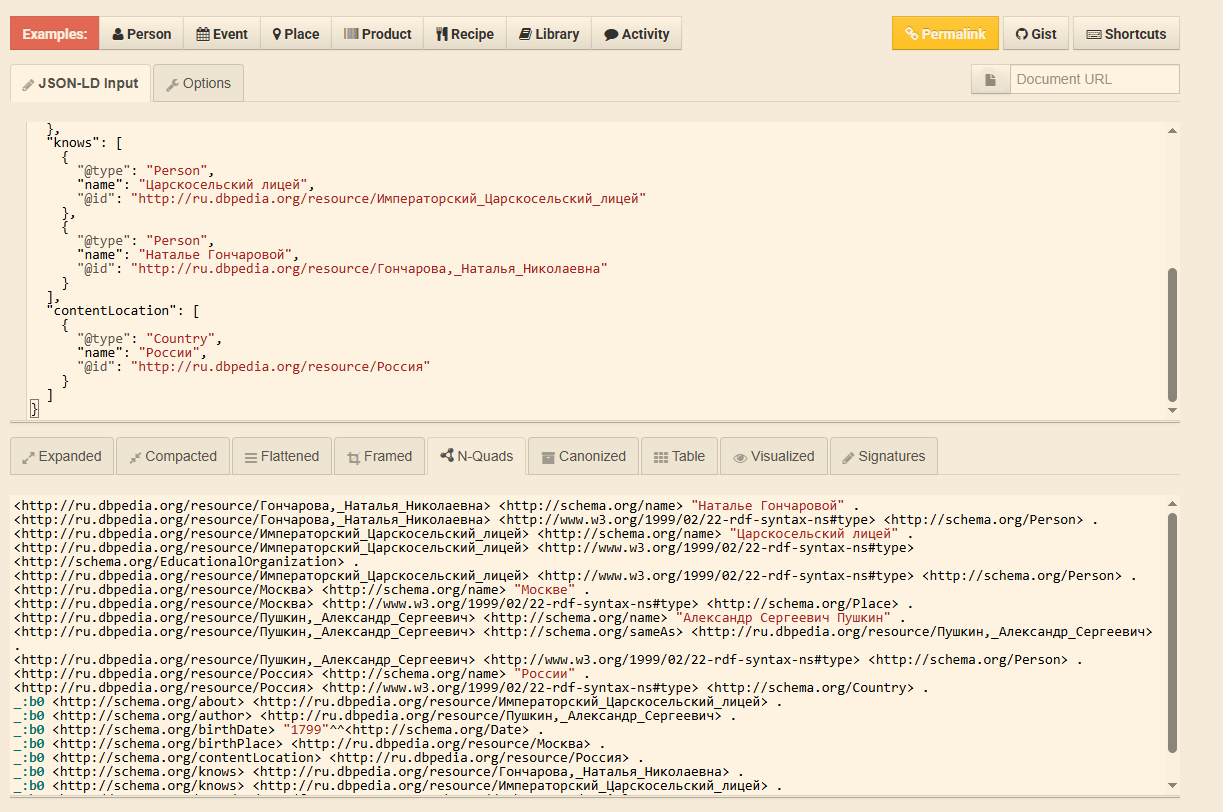

<p class="task" id="4"></p>

4\. Выделите сущности в тексте из задания 1, воспользовавшись предобученной моделью из пакета 🤗 Transformers. Для решения задачи можно использовать Inference API или развернуть любую модель локально. Обратите внимание, что модель должна быть универсальной и поддерживать работу с русским языком.

Выведите на экран результат работы модели.



- [ ] Проверено на семинаре

In [ ]:
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline
from typing import List, Dict
import json


In [18]:

# Используем рабочую русскоязычную модель для NER
model_name = "Gherman/bert-base-NER-Russian"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForTokenClassification.from_pretrained(model_name)

ner_pipe = pipeline("ner", model=model, tokenizer=tokenizer, aggregation_strategy="simple")

ner_results: List[Dict[str, Any]] = ner_pipe(text)

Device set to use cpu


In [20]:
# Преобразуем score в float, чтобы можно было сериализовать в JSON
ner_results_serializable = [
    {**e, "score": float(e["score"])} for e in ner_results
]

print(json.dumps(ner_results_serializable, ensure_ascii=False, indent=2))

# сохраняем для дальнейшего использования
ner_output = ner_results_serializable

[
  {
    "entity_group": "FIRST_NAME",
    "score": 0.9946337938308716,
    "word": "Александр",
    "start": 0,
    "end": 9
  },
  {
    "entity_group": "MIDDLE_NAME",
    "score": 0.995971143245697,
    "word": "Сергеевич",
    "start": 10,
    "end": 19
  },
  {
    "entity_group": "LAST_NAME",
    "score": 0.9952439069747925,
    "word": "Пушкин",
    "start": 20,
    "end": 26
  },
  {
    "entity_group": "COUNTRY",
    "score": 0.9944568872451782,
    "word": "России",
    "start": 154,
    "end": 160
  },
  {
    "entity_group": "LAST_NAME",
    "score": 0.9952290058135986,
    "word": "Пушкин",
    "start": 253,
    "end": 259
  },
  {
    "entity_group": "CITY",
    "score": 0.9979559183120728,
    "word": "Москве",
    "start": 270,
    "end": 276
  },
  {
    "entity_group": "LAST_NAME",
    "score": 0.9945275783538818,
    "word": "Пушкин",
    "start": 444,
    "end": 450
  },
  {
    "entity_group": "LAST_NAME",
    "score": 0.991815447807312,
    "word": "Пушкин",
    

<p class="task" id="5"></p>

5\. Для каждой сущности, выделенной в предыдущем задании, найдите соответствующий идентификатор в Wikidata. Для поиска воспользуйтесь [MediaWiki API](https://www.wikidata.org/w/api.php?action=help&modules=wbsearchentities). В качестве подходящей сущности используйте первое значение в выдаче.

Для каждой сущности также найдите значение отношения P31 (instance of).

Выведите на экран результаты в виде `pd.DataFrame` со следующими столбцами: text, qid, title, label, description (если есть), classes.


- [ ] Проверено на семинаре

In [21]:
import pandas as pd

In [27]:
import requests
import pandas as pd
from typing import List, Dict, Any

def get_wikidata_qid(entity: str) -> Dict[str, Any]:
    """Поиск сущности в Wikidata"""
    url = "https://www.wikidata.org/w/api.php"
    params = {
        "action": "wbsearchentities",
        "search": entity,
        "language": "ru",
        "format": "json",
        "limit": 1
    }
    resp = requests.get(url, params=params).json()
    if "search" in resp and resp["search"]:
        return resp["search"][0]
    return {}

def get_instance_of(qid: str) -> List[str]:
    """Получение значения свойства P31 (instance of)"""
    url = "https://www.wikidata.org/w/api.php"
    params = {
        "action": "wbgetclaims",
        "entity": qid,
        "property": "P31",
        "format": "json"
    }
    resp = requests.get(url, params=params).json()
    classes = []
    if "claims" in resp and "P31" in resp["claims"]:
        for claim in resp["claims"]["P31"]:
            if "mainsnak" in claim and "datavalue" in claim["mainsnak"]:
                classes.append(claim["mainsnak"]["datavalue"]["value"]["id"])
    return classes

# Собираем уникальные сущности из ner_output
unique_entities = list({e["word"] for e in ner_output if len(e["word"].strip()) > 0})

rows = []
for entity in unique_entities:
    qdata = get_wikidata_qid(entity)
    qid = qdata.get("id")
    title = qdata.get("title")
    label = qdata.get("label")
    description = qdata.get("description")
    classes = get_instance_of(qid) if qid else []

    rows.append({
        "text": entity,
        "qid": qid,
        "title": title,
        "label": label,
        "description": description,
        "classes": classes
    })

df_wikidata = pd.DataFrame(rows)
df_wikidata


JSONDecodeError: Expecting value: line 1 column 1 (char 0)

<p class="task" id="6"></p>

6\. Представьте результат решения задачи 5 в виде JSON-LD. Структура формата должна иметь следующий вид:

```json
{
  "@context": {
    "wdt": "http://www.wikidata.org/prop/direct/",
    "wd": "http://www.wikidata.org/entity/",
    "schema": "http://schema.org/",
    "rdfs": "http://www.w3.org/2000/01/rdf-schema#"
  },
  "@graph": [
    {
      "@id": "wd:Q1",
      "rdfs:label": "...",
      "wdt:P31": [
        "wd:Q1",
        "wd:Q2",
        "wd:Q3"
      ]
    },
    ...
  ]
}
```

Используя данное представление, создайте граф при помощи `rdflib`. Сериализуйте полученный граф в формате turtle и сохраните на диск.

- [ ] Проверено на семинаре